# CLSBIWeakLens Tutorial

We are going to walk through a simple example of performing inference with CLSBIWeakLens.

First, let's make sure that we have all of our dependencies ready.

In [ ]:
# Update PIP
%pip install --upgrade pip -q

# Cosmology
%pip install colossus -q

# Inference
%pip install sbi -q
%pip install emcee -q

# Plotting
%pip install pygtc -q
%pip install chainconsumer -q
%pip install --upgrade ipython -q

In [ ]:
import numpy as np
import json
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

# Simulation

To train our inferrer for Simulation-Based Inference (SBI), we'll need to generate some simulations. These are the data points from which we can learn the relationship between NFW profiles (observables) and log10mass-concentration pairs (parameters) that we'll use later in this tutorial for inference.

## Configuration

First, we'll load in an example simulation config and look at the example config values. For the different numerical experiments, we'll tweak these and use different combinations of configs, but this is a good representative example of what a sim config could be.

In [124]:
# Command line arguments for generating simulations
SIM_ID = 'sim_z1'
NUM_SIMS = 10000

with open(f'configs/simulations/{SIM_ID}.json', 'r') as f:
    sim_config = json.load(f)
    
print(json.dumps(sim_config, indent=2))

{
  "mc_relation": "child18",
  "mc_scatter": 0.1,
  "min_log10mass": 13,
  "max_log10mass": 16,
  "num_radial_bins": 30,
  "profile_noise_dex": 0.3,
  "mc_pair_subselect": "all",
  "min_z": 0.2,
  "max_z": 0.35
}


## Generating Simulations

To use this sim_config to generate our simulations, we do the following:
1) randomly select `NUM_SIMS` log10masses in the defined range (`min_log10mass`, `max_log10mass`)
2) use the `mc_relation` (with some `mc_scatter` and redshift, `z`) to find the corresponding concentrations
3) filter these mc_pairs based on the `mc_pair_subselect` criteria
4) generate NFW profiles with `num_radial_bins` radial bins and some `profile_noise_dex` applied to them
6) output the `sample_mc_pairs` and the `simulated_nfw_profiles` as `.npy` files

In [125]:
%run scripts/gen_simulations.py --sim_id {SIM_ID} --num_sims {NUM_SIMS} --regenerate

# Confirming the output files were generated correctly
sim_output_dir = f'outputs/simulations/{SIM_ID}.{NUM_SIMS}'
%ls {sim_output_dir}

Overwriting existing simulation because of --regenerate flag
sample_mc_pairs.npy         simulated_nfw_profiles.npy


Let's look at the `sample_mc_pairs` to make sure they look correct. We expect to see our predicted log10mass-concentration relation with some scatter applied to it.

(10000, 2)
[[14.93996807  4.32874451]
 [13.86250645  5.28729269]
 [13.24259073  6.07611466]
 [13.67707303  5.55403392]
 [15.93422363  3.88254974]]


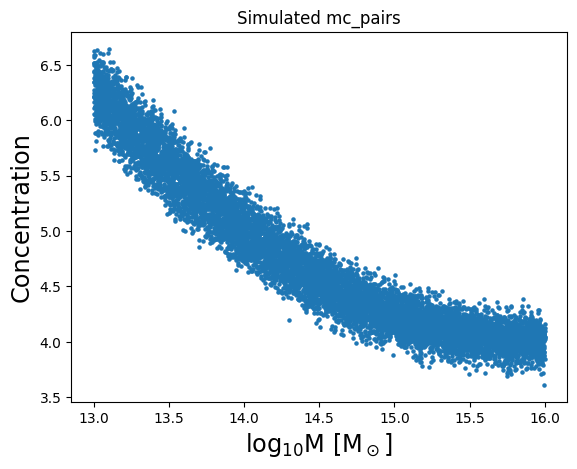

In [7]:
sample_mc_pairs = np.load(f'{sim_output_dir}/sample_mc_pairs.npy')

# Expected shape: (NUM_SIMS, 2)
print(np.shape(sample_mc_pairs))

# 5 example mc_pairs
print(sample_mc_pairs[:5])

# mc_pairs scatter plot
plt.scatter(sample_mc_pairs[:,0], sample_mc_pairs[:,1],s=5)
plt.xlabel('log$_{10}$M [M$_\odot$]', fontsize='xx-large')
plt.ylabel('Concentration', fontsize='xx-large')
plt.title('Simulated mc_pairs')
plt.show()

# Observations

Now, let's generate some "observations", which are mock NFW profiles that we'll treat as empirical data. We'll use these for both MCMC and SBI later in the notebook.

## Configuration
Similar to our approach above, let's look at an example observation config so we can inspect what we can tweak in numerical experiments.

In [8]:
# Command line arguments for generating simulations
OBS_ID = 'obs_z1_lambda5'
NUM_OBS = 10

with open(f'configs/observations/{OBS_ID}.json', 'r') as f:
    obs_config = json.load(f)
    
print(json.dumps(obs_config, indent=2))

{
  "rm_relation": "mcclintock18",
  "mc_relation": "child18",
  "min_richness": 30,
  "max_richness": 45,
  "rm_scatter": 0.1,
  "mc_scatter": 0.1,
  "profile_noise_dex": 0.3,
  "num_radial_bins": 30,
  "min_z": 0.2,
  "max_z": 0.35
}


## Generating Observations

To use this obs_config to generate our observations, we do the following:
1) randomly select `NUM_OBS` richnesses ($\lambda$) in the defined range (`min_richness`, `max_richness`)
2) use the `rm_relation` (with some `rm_scatter`) to find the corresponding log10masses
3) use the `mc_relation` (with some `mc_scatter` and redshift, `z`) to find the corresponding concentrations
4) generate NFW profiles with `num_radial_bins` radial bins and some `profile_noise_dex` applied to them
5) output the `drawn_mc_pairs` and the `drawn_nfw_profiles` as `.npy` files

In [10]:
%run scripts/gen_observations.py --obs_id {OBS_ID} --num_obs {NUM_OBS} --regenerate

Overwriting existing observations because of --regenerate flag


In [11]:
# Confirming the output files were generated correctly
obs_output_dir = f'outputs/observations/{OBS_ID}.{NUM_OBS}'
%ls {obs_output_dir}

drawn_mc_pairs.npy                log_sigmas.npy
drawn_mc_pairs.pdf                noiseless_drawn_nfw_profiles.npy
drawn_mc_pairs.png                noiseless_drawn_nfw_profiles.pdf
drawn_nfw_profiles.npy            noiseless_drawn_nfw_profiles.png
drawn_nfw_profiles.pdf            sigmas.npy
drawn_nfw_profiles.png


First, let's look at the drawn_mc_pairs from the given richness bin. 

Note that we generate these plots (`drawn_mc_pairs.png`, `drawn_nfw_profiles.png`) automatically using `plotutils.py`, but it's helpful to replot manually here to build familiarity with the core data objects.

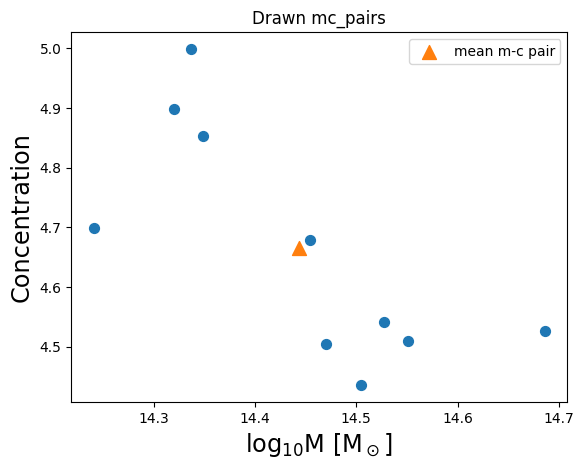

In [112]:
drawn_mc_pairs = np.load(f'{obs_output_dir}/drawn_mc_pairs.npy')
drawn_nfw_profiles = np.load(f'{obs_output_dir}/drawn_nfw_profiles.npy')


# drawn_mc_pairs scatter plot
plt.scatter(drawn_mc_pairs[:,0], drawn_mc_pairs[:,1],s=50)
plt.scatter(
    np.mean(drawn_mc_pairs[:, 0]),
    np.mean(drawn_mc_pairs[:, 1]),
    s=100,
    marker='^',
    label='mean m-c pair',
)
plt.legend()
plt.xlabel('log$_{10}$M [M$_\odot$]', fontsize='xx-large')
plt.ylabel('Concentration', fontsize='xx-large')
plt.title('Drawn mc_pairs')
plt.show()

Next, we can look at the drawn_nfw_profiles which we generated from the above drawn_mc_pairs. 

Here, each individual NFW profile is noisy so we can perform stacking to marginalize over this noise. One approach to stacking is that we can first stack the observables and perform inference on that median NFW profile. We call this approach "join-then-fit" because we first join the observables and then fit on that "joined" observable.

In [23]:
# Expected shape: (NUM_OBS, num_radial_bins)
print(np.shape(drawn_nfw_profiles))

(10, 30)


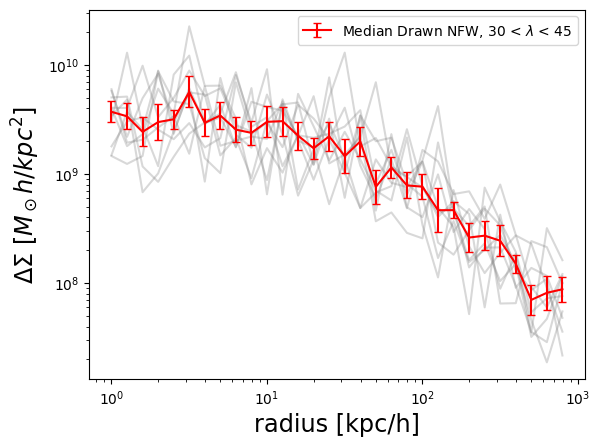

In [123]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck18')

rbins = 10**np.arange(0, sim_config['num_radial_bins'] / 10, 0.1)
plt.figure()
plt.loglog()
plt.xlabel('radius [kpc/h]', fontsize='xx-large')
plt.ylabel('$ \Delta \Sigma$ [$M_\odot h / kpc^2$]', fontsize='xx-large')

# Plot each individual observation
for nfw_profile in drawn_nfw_profiles:
    plt.plot(rbins, nfw_profile, '-', alpha=0.3, color='gray')

# Calculate error bars
sigmas = np.std(drawn_nfw_profiles, axis=0)
log_sigmas = np.std(np.log10(drawn_nfw_profiles), axis=0)
upper_error = np.exp(
    np.log(np.median(drawn_nfw_profiles, axis=0)) + log_sigmas) - np.median(
        drawn_nfw_profiles, axis=0)
lower_error = np.median(drawn_nfw_profiles, axis=0) - np.exp(
    np.log(np.median(drawn_nfw_profiles, axis=0)) - log_sigmas)
yerr = [lower_error, upper_error]

# Plot median observation with error bars
plt.errorbar(
    rbins,
    np.median(drawn_nfw_profiles, axis=0),
    yerr=yerr,
    fmt='r',
    capsize=3.,
    label=f'Median Drawn NFW, {obs_config["min_richness"]} < $\lambda$ < {obs_config["max_richness"]}'
)
plt.legend();

# Inference

Now we'll need to infer the relationship between the input log10mass-concentration pairs and the output NFW profiles. MCMC will perform this inference using an analytic likelihood function. SBI will perform inference this with a neural network inferrer that has been trained on the simulated data points and their corresponding NFW profiles. Both of these inference techniques will have the observations applied to them, which can then show us the posterior distribution.

## Configuration

Similarly to what we did before, we'll generate an infer_config in our directory of interest and look at an example of what these values could be.

In [25]:
# Command line arguments for generating simulations
INFER_ID = 'infer_z1'

with open(f'configs/inference/{INFER_ID}.json', 'r') as f:
    infer_config = json.load(f)
    
print(json.dumps(infer_config, indent=2))

{
  "priors": {
    "min_log10mass": 10,
    "max_log10mass": 20,
    "mc_scatter": 0.1,
    "mc_relation": "child18",
    "min_concentration": 0,
    "max_concentration": 10,
    "min_z": 0.2,
    "max_z": 0.35
  }
}


## Run Inference

To actually run inference, we do the following:
1) train the SBI inferrer, which (despite the misleading nomenclature of "posterior") is actually just the trained inferrer (i.e. it will become the posterior later when we apply it to observations)
2) run inference
    1) with MCMC (using the likelihood function and observations)
    2) with SBI (using simulations, observations, and trained inferrer)

The reason we split these two steps is so we can train an SBI inferrer and apply it to many different sets of observations without redundant computing.

In [27]:
%run scripts/gen_posterior.py --sim_id {SIM_ID} --infer_id {INFER_ID} --num_sims {NUM_SIMS} --regenerate

Overwriting existing posterior because of --regenerate flag
 Neural network successfully converged after 48 epochs.

This is a pretty time intensive step (~5 minutes). If you want to stretch your legs and/or refill your cup of coffee, this is the perfect time to do so. We are using SBI and MCMC to perform inference here on NUM_OBS + 1 observations: one for each of the observations and one for the median of these observations.

While you're enjoying your coffee and running this step, we can discuss the second method of stacking. We already mentioned "join-then-fit" where we stack observations first and perform inference on that joined observation. The second stacking technique we use is called "fit-then-join" where we perform inference on each individual observation and then stack the posteriors afterwards. We discuss the pros and cons of each technique for each SBI and MCMC in the paper, but at a high level, we find that join-then-fit results in tighter constraints, but has the potential to include some bias. Fit-then-join, by contrast, is often less constrained in parameter space, but is less vulnerable to bias.

In [29]:
%run scripts/run_inference.py --sim_id {SIM_ID} --infer_id {INFER_ID} --obs_id {OBS_ID} --num_sims {NUM_SIMS} --num_obs {NUM_OBS} --regenerate
print("Completed running inference")

Overwriting existing inference outputs because of --regenerate flag


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

/Users/akumgill/Library/Python/3.9/lib/python/site-packages/pyknos/mdn/mdn.py:283: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2197.)
  zero_mean_samples, _ = torch.triangular_solve(


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

...

## burning in ... 


100%|█████████████████████████████████| 100/100 [00:15<00:00,  6.66it/s]


## running the full chain ... 


100%|█████████████████████████████████| 200/200 [00:30<00:00,  6.49it/s]

Completed running inference


## Plotting

Now we can plot the confusogram/corner plots/banana plots.

In [56]:
# Turning off interactive plotting so we can be more intentional
# plt.ioff();
%run scripts/plot_chains.py --sim_id {SIM_ID} --infer_id {INFER_ID} --obs_id {OBS_ID} --num_sims {NUM_SIMS} --num_obs {NUM_OBS} --regenerate
plt.close()
# plt.ion();

Overwriting existing plots because of --regenerate flag


As before, let's first see what plots were generated. We see mostly files like `{inference}_{plotting}.{filetype}` (e.g. `mcmc_cc.pdf`). There is also a file called `mcmc_sbi_cc.{filetype}` which shows both MCMC and SBI inference together, but this can be tricky to parse. We also see a `diagnostics/` folder which we will look into shortly.

In [126]:
# Confirming the output files were generated correctly
plots_output_dir = f'outputs/plots/{SIM_ID}.{INFER_ID}.{OBS_ID}.{NUM_SIMS}.{NUM_OBS}'
%ls {plots_output_dir}/diagnostics

drawn_nfw_profiles.pdf     mcmc_jtf_mcmc_walkers.pdf
drawn_nfw_profiles.png     mcmc_jtf_mcmc_walkers.png
mcmc_ftj_cc.pdf            sbi_ftj_cc.pdf
mcmc_ftj_cc.png            sbi_ftj_cc.png


MCMC corner plot using ChainConsumer


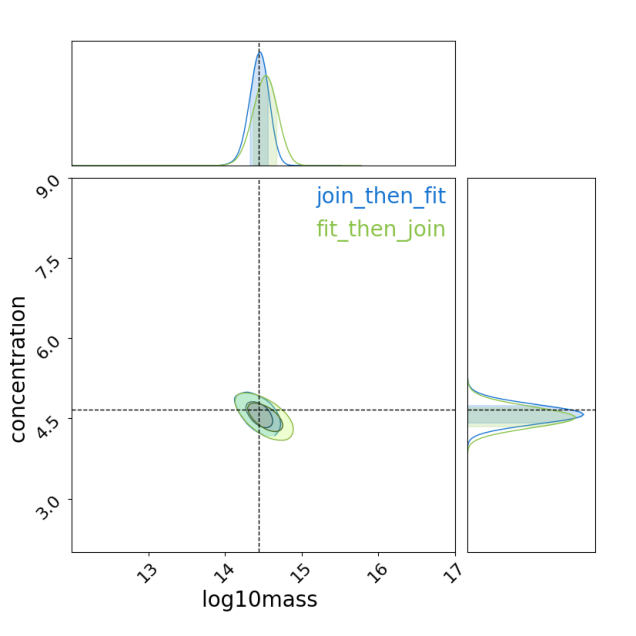

SBI corner plot using ChainConsumer


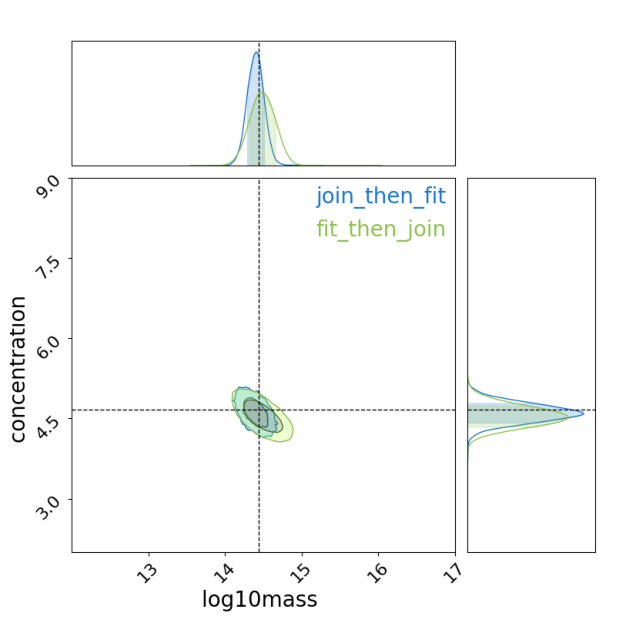

MCMC and SBI corner plot using ChainConsumer. As you can see, this gets hard to parse, but is useful to show that the inference is consistent for this configuration across these two inference techniques.


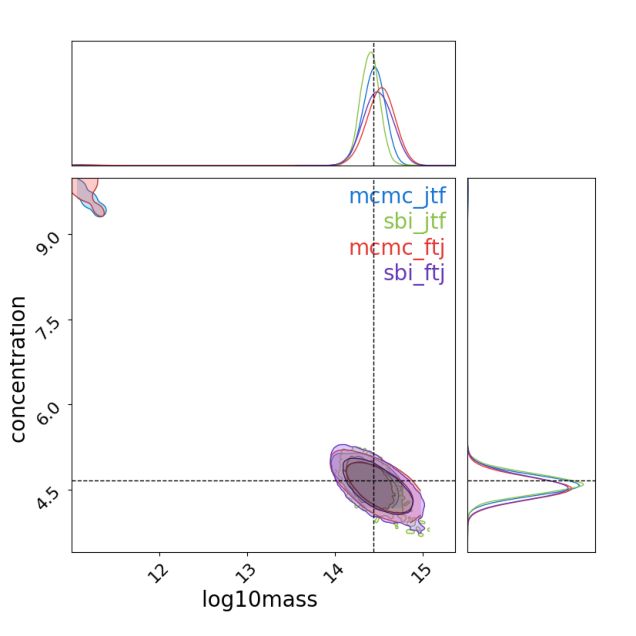

In [90]:
print('MCMC corner plot using ChainConsumer')
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(f'{plots_output_dir}/mcmc_cc.png'))
plt.axis('off')
plt.show()

print('SBI corner plot using ChainConsumer')
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(f'{plots_output_dir}/sbi_cc.png'))
plt.axis('off')
plt.show()

print('MCMC and SBI corner plot using ChainConsumer. As you can see, this gets hard to parse, but is useful to show that the inference is consistent for this configuration across these two inference techniques.')
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(f'{plots_output_dir}/mcmc_sbi_cc.png'))
plt.axis('off')
plt.show()

Finally, we can also look at the diagnostic plots. Here, we have some useful files:
* Drawn NFW profiles shows us whether the NFWs from our inferred log10mass and concentration are comparable with the observed ones
* MCMC walkers will show us whether we have a sufficient number of steps for MCMC to actually converge
* {inference}_ftj_cc shows us the inferred log10mass and concentration for each individual observation. These posteriors are subsequently stacked in the "fit-then-join" stacking technique.

In [88]:
%ls {plots_output_dir}/diagnostics

drawn_nfw_profiles.pdf     mcmc_jtf_mcmc_walkers.pdf
drawn_nfw_profiles.png     mcmc_jtf_mcmc_walkers.png
mcmc_ftj_cc.pdf            sbi_ftj_cc.pdf
mcmc_ftj_cc.png            sbi_ftj_cc.png


Inferred NFW profiles: We can see that the inferred parameters are consistent with the observations, which is exactly what we would expect.


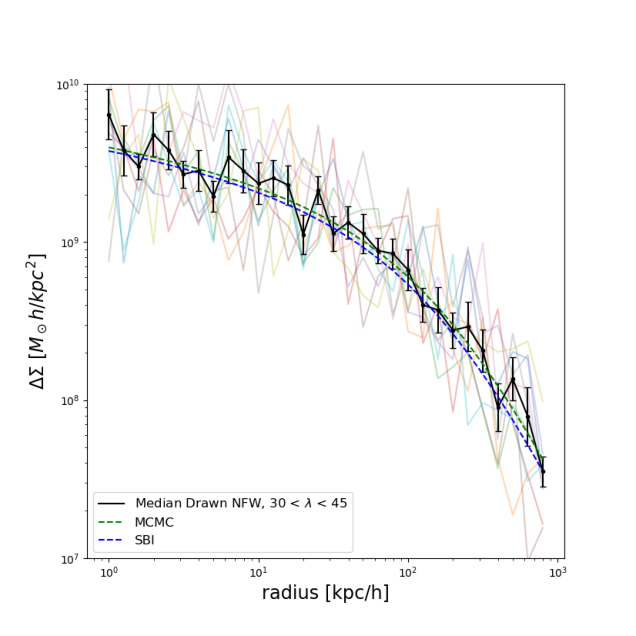

MCMC Walkers: We see that after the burnout phase, our MCMC walkers have all converged on the relevant part of posterior space and are successfully exploring that region.


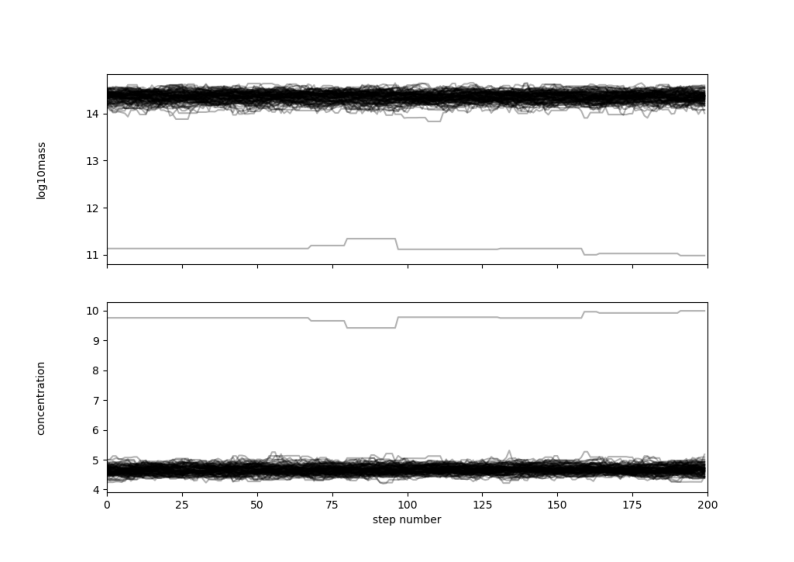

SBI contours for individual observations: These posteriors are subsequently stacked for fit-then-join (shown above).


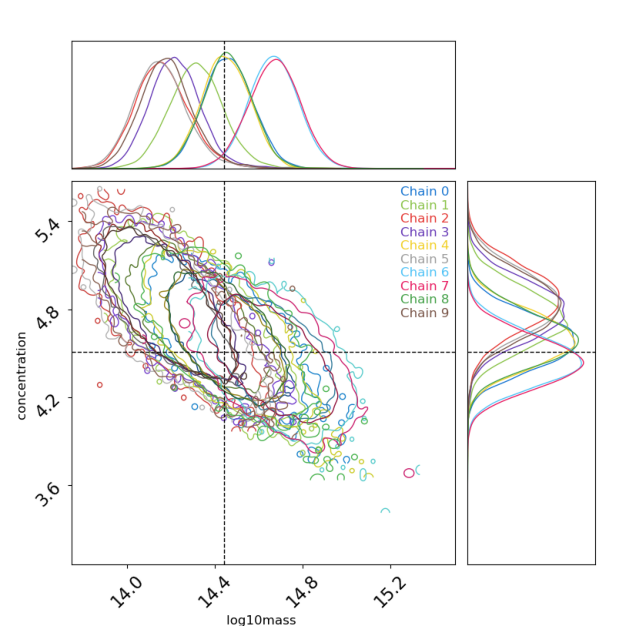

In [98]:
print('Inferred NFW profiles: We can see that the inferred parameters are consistent with the observations, which is exactly what we would expect.')
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(f'{plots_output_dir}/diagnostics/drawn_nfw_profiles.png'))
plt.axis('off')
plt.show()

print('MCMC Walkers: We see that after the burnout phase, our MCMC walkers have all converged on the relevant part of posterior space and are successfully exploring that region.')
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(f'{plots_output_dir}/diagnostics/mcmc_jtf_mcmc_walkers.png'))
plt.axis('off')
plt.show()

print('SBI contours for individual observations: These posteriors are subsequently stacked for fit-then-join (shown above).')
plt.figure(figsize=(10, 8))
plt.imshow(mpimg.imread(f'{plots_output_dir}/diagnostics/sbi_ftj_cc.png'))
plt.axis('off')
plt.show()